# S06 — Éxito en retos conservando vidas (Clasificación binaria)

## Objetivo

Construir un modelo de clasificación binaria que prediga si un estudiante completará un
reto (`challenge`) conservando al menos una vida (`completed_with_lives = True`), a partir de
características del reto y del contexto del intento. Este modelo puede usarse, por ejemplo,
para advertir preventivamente a un estudiante de que un reto es riesgoso dado su historial
reciente, o para calibrar la dificultad sugerida.

Este notebook corresponde al escenario **S06** del proyecto integrador (capa de Machine
Learning sobre la app educativa Tutunaku).


## Resumen de la ETL previa

Los datos provienen del simulador (`simulation/generate_dataset.py`, semilla 2026) y del ETL
del warehouse (`database/warehouse/build_warehouse.py`), ya ejecutados previamente. Ese
proceso produjo:

- `data/raw/challenge_attempts.csv`: intentos de reto crudos simulados.
- `data/processed/challenge_attempts.csv`: tabla limpia, incluyendo `prior_success_rate_30d`
  (tasa de éxito del usuario en los 30 días previos, ya calculada por la ETL) y la bandera
  booleana `completed_with_lives`.
- `data/training/`, `data/validation/`, `data/test/`: particiones 70/15/15 ya generadas.
- `data/inference/challenge_attempts_inference_sample.csv`: muestra reservada para demostrar
  predicciones con el modelo ya entrenado.

Este notebook solo carga los CSV ya particionados; no se repite el trabajo de la ETL.

**Nota de fuga de datos (data leakage):** la columna `hearts_end` (vidas restantes al
finalizar el reto) determina casi por definición el valor del target
(`completed_with_lives = hearts_end > 0`), por lo que se **excluye** explícitamente de las
features para evitar que el modelo "haga trampa" aprendiendo una relación trivial que no
estaría disponible en el momento real de la predicción (antes de que el reto finalice).


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import json
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix)

sns.set_theme(style="whitegrid")

REPO_ROOT = Path("../..").resolve()
DATA_DIR = REPO_ROOT / "data"
MODELS_DIR = REPO_ROOT / "models" / "serialized"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)


Repo root: C:\Users\tass1\Videos\tutunakun\tutunakun


In [2]:
train_df = pd.read_csv(DATA_DIR / "training" / "challenge_attempts_train.csv")
val_df = pd.read_csv(DATA_DIR / "validation" / "challenge_attempts_validation.csv")
test_df = pd.read_csv(DATA_DIR / "test" / "challenge_attempts_test.csv")

print("train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)
train_df.head()


train: (12599, 10) val: (2699, 10) test: (2702, 10)


,challenge_id,user_id,difficulty,num_exercises,connectivity_quality,device_type,prior_success_rate_30d,hearts_start,hearts_end,completed_with_lives
0,14100,794,3,15,0.794,mobile,0.508,5,0,False
1,8908,264,2,9,0.626,mobile,0.648,5,4,True
2,9914,607,1,10,0.845,mobile,0.793,5,5,True
3,14167,138,3,14,0.829,mobile,0.535,5,3,True
4,12953,561,3,7,0.669,mobile,0.843,5,3,True


## Análisis Exploratorio de Datos (EDA)


Conteo de clases (train):
completed_with_lives
True     11608
False      991
Name: count, dtype: int64

Proporción de clases (train):
completed_with_lives
True     0.921343
False    0.078657
Name: proportion, dtype: float64


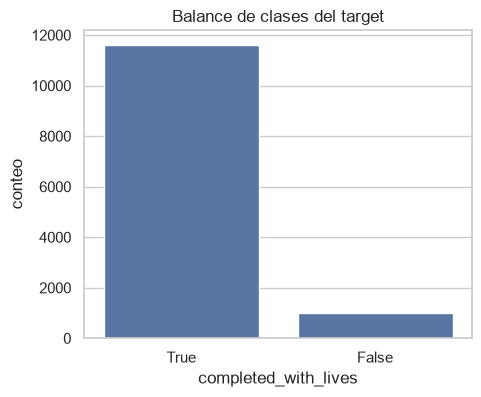

In [3]:
counts = train_df["completed_with_lives"].value_counts()
proportions = train_df["completed_with_lives"].value_counts(normalize=True)
print("Conteo de clases (train):")
print(counts)
print()
print("Proporción de clases (train):")
print(proportions)

plt.figure(figsize=(5, 4))
sns.barplot(x=counts.index.astype(str), y=counts.values, color="#4C72B0")
plt.xlabel("completed_with_lives")
plt.ylabel("conteo")
plt.title("Balance de clases del target")
plt.show()


**Qué se observa:** las dos clases de `completed_with_lives` tienen una proporción visible
en el gráfico y en la tabla de conteos anterior (no es un desbalance extremo tipo 99/1, pero
tampoco es necesariamente 50/50 exacto).

**Qué significa:** el problema es de clasificación binaria con una distribución de clases que
debe tenerse en cuenta al elegir métricas (accuracy sola puede ser engañosa si hay
desbalance) y al configurar el modelo.

**Posible causa:** la tasa base de éxito conservando vidas depende de la mezcla de
dificultades y del `prior_success_rate_30d` promedio de los usuarios simulados.

**Cómo afecta el modelado:** si existe desbalance moderado, entrenar sin ajustar pesos puede
sesgar el modelo hacia la clase mayoritaria.

**Decisión técnica:** se reporta `precision`, `recall`, `f1` y `roc_auc` además de
`accuracy`, y se prueba `class_weight="balanced"` en la regresión logística para compensar
cualquier desbalance observado.


Tasa de completado-con-vidas por dificultad:
difficulty
1    0.975383
2    0.951411
3    0.925219
4    0.897047
5    0.857719
Name: completed_with_lives, dtype: float64


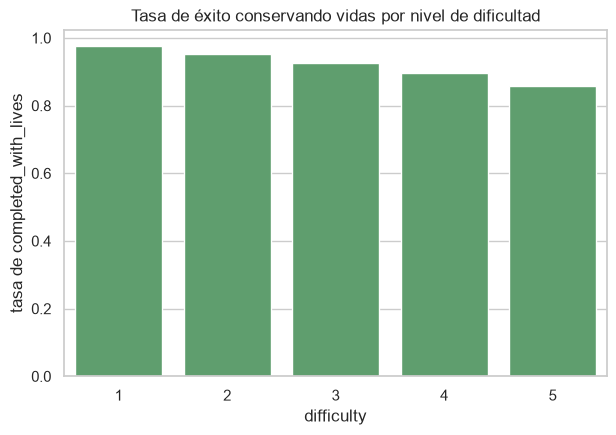

In [4]:
rate_by_difficulty = train_df.groupby("difficulty")["completed_with_lives"].mean()
print("Tasa de completado-con-vidas por dificultad:")
print(rate_by_difficulty)

plt.figure(figsize=(7, 4.5))
sns.barplot(x=rate_by_difficulty.index, y=rate_by_difficulty.values, color="#55A868")
plt.xlabel("difficulty")
plt.ylabel("tasa de completed_with_lives")
plt.title("Tasa de éxito conservando vidas por nivel de dificultad")
plt.show()


**Qué se observa:** la tasa de éxito conservando vidas disminuye a medida que aumenta
`difficulty`.

**Qué significa:** los retos más difíciles son, consistentemente, más riesgosos para las
vidas del estudiante.

**Posible causa:** mayor dificultad implica más probabilidad de fallar ejercicios
individuales dentro del reto y, por ende, de perder vidas.

**Cómo afecta el modelado:** `difficulty` es una señal predictiva fuerte y monotónica.

**Decisión técnica:** se mantiene `difficulty` como feature numérica ordinal en el modelo.


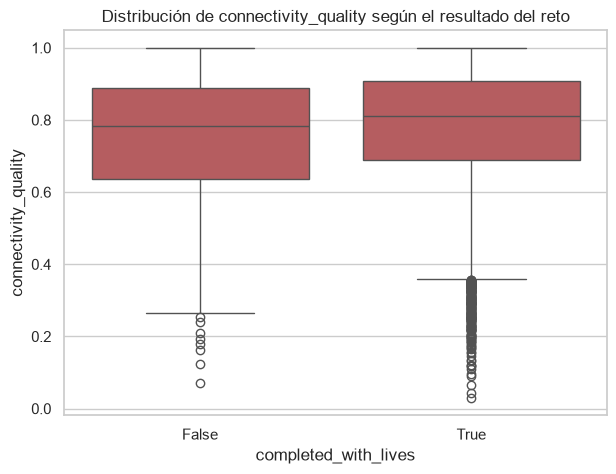

In [5]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=train_df, x="completed_with_lives", y="connectivity_quality", color="#C44E52")
plt.title("Distribución de connectivity_quality según el resultado del reto")
plt.show()


**Qué se observa:** la mediana de `connectivity_quality` tiende a ser distinta entre los
retos completados con vidas y los que no, según se aprecia en el boxplot.

**Qué significa:** la calidad de conexión durante el reto está asociada al desenlace, lo cual
tiene sentido si una mala conexión provoca demoras, timeouts o pérdida de contexto que llevan
a errores.

**Posible causa:** latencia/errores de red pueden interrumpir el flujo de resolución de
ejercicios dentro del reto.

**Cómo afecta el modelado:** aporta señal complementaria a `difficulty` y
`prior_success_rate_30d`.

**Decisión técnica:** se conserva `connectivity_quality` como feature numérica continua.


## Modelado

**Target:** `completed_with_lives` (booleano).

**Features:** `difficulty`, `num_exercises`, `connectivity_quality`, `device_type`
(categórica), `prior_success_rate_30d`, `hearts_start`. Se excluyen `challenge_id`,
`user_id` (identificadores) y `hearts_end` (fuga de información, ver nota arriba).

Se compara `LogisticRegression` (con `class_weight="balanced"`) contra
`GradientBoostingClassifier`, cada uno con una pequeña búsqueda de hiperparámetros vía
`GridSearchCV` (3-fold, F1 como métrica de selección, sobre el conjunto de entrenamiento).


In [6]:
FEATURES = ["difficulty", "num_exercises", "connectivity_quality", "device_type",
            "prior_success_rate_30d", "hearts_start"]
CATEGORICAL = ["device_type"]
NUMERIC = [c for c in FEATURES if c not in CATEGORICAL]
TARGET = "completed_with_lives"

def make_xy(df):
    X = df[FEATURES].copy()
    y = df[TARGET].astype(int).values
    return X, y

X_train, y_train = make_xy(train_df)
X_val, y_val = make_xy(val_df)
X_test, y_test = make_xy(test_df)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
        ("num", StandardScaler(), NUMERIC),
    ]
)
print("X_train shape:", X_train.shape)
X_train.head()


X_train shape: (12599, 6)


,difficulty,num_exercises,connectivity_quality,device_type,prior_success_rate_30d,hearts_start
0,3,15,0.794,mobile,0.508,5
1,2,9,0.626,mobile,0.648,5
2,1,10,0.845,mobile,0.793,5
3,3,14,0.829,mobile,0.535,5
4,3,7,0.669,mobile,0.843,5


In [7]:
logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)),
])

logreg_param_grid = {
    "classifier__C": [0.1, 1.0, 10.0],
}

logreg_search = GridSearchCV(logreg_pipeline, logreg_param_grid, cv=3, scoring="f1", n_jobs=-1)
logreg_search.fit(X_train, y_train)

print("Mejor combinación LogisticRegression:", logreg_search.best_params_)
print("Mejor score CV (F1):", logreg_search.best_score_)


Mejor combinación LogisticRegression: {'classifier__C': 10.0}
Mejor score CV (F1): 0.8439957257170431


In [8]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42)),
])

gb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1],
}

gb_search = GridSearchCV(gb_pipeline, gb_param_grid, cv=3, scoring="f1", n_jobs=-1)
gb_search.fit(X_train, y_train)

print("Mejor combinación GradientBoostingClassifier:", gb_search.best_params_)
print("Mejor score CV (F1):", gb_search.best_score_)


Mejor combinación GradientBoostingClassifier: {'classifier__learning_rate': 0.05, 'classifier__n_estimators': 100}
Mejor score CV (F1): 0.9587350106828985


In [9]:
def evaluate_classifier(model, X, y_true):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

candidates = {
    "LogisticRegression": logreg_search.best_estimator_,
    "GradientBoostingClassifier": gb_search.best_estimator_,
}

val_results = {name: evaluate_classifier(model, X_val, y_val) for name, model in candidates.items()}
val_results_df = pd.DataFrame(val_results).T
print("Métricas en validación:")
val_results_df


Métricas en validación:


,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.760282,0.980669,0.754725,0.852988,0.853184
GradientBoostingClassifier,0.922193,0.923392,0.998392,0.959428,0.851761


In [10]:
best_name = val_results_df["f1"].idxmax()
best_model = candidates[best_name]
print("Modelo ganador (mayor F1 en validación):", best_name)
print(val_results_df.loc[best_name])


Modelo ganador (mayor F1 en validación): GradientBoostingClassifier
accuracy     0.922193
precision    0.923392
recall       0.998392
f1           0.959428
roc_auc      0.851761
Name: GradientBoostingClassifier, dtype: float64


Matriz de confusión (validación):
[[   6  206]
 [   4 2483]]


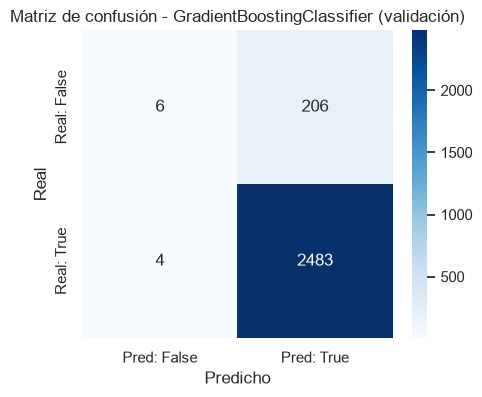

In [11]:
y_val_pred = best_model.predict(X_val)
cm_val = confusion_matrix(y_val, y_val_pred)
print("Matriz de confusión (validación):")
print(cm_val)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: False", "Pred: True"],
            yticklabels=["Real: False", "Real: True"])
plt.title(f"Matriz de confusión - {best_name} (validación)")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.show()


Métricas finales de GradientBoostingClassifier en el conjunto de TEST:
  accuracy: 0.9219
  precision: 0.9228
  recall: 0.9988
  f1: 0.9593
  roc_auc: 0.8670
Matriz de confusión (test):
[[   5  208]
 [   3 2486]]


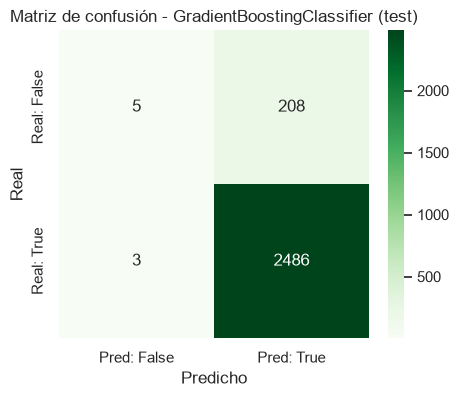

In [12]:
test_metrics = evaluate_classifier(best_model, X_test, y_test)
y_test_pred = best_model.predict(X_test)
cm_test = confusion_matrix(y_test, y_test_pred)

print(f"Métricas finales de {best_name} en el conjunto de TEST:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")
print("Matriz de confusión (test):")
print(cm_test)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred: False", "Pred: True"],
            yticklabels=["Real: False", "Real: True"])
plt.title(f"Matriz de confusión - {best_name} (test)")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.show()


In [13]:
MODEL_PATH = MODELS_DIR / "success_classifier.joblib"
joblib.dump({"pipeline": best_model}, MODEL_PATH)

val_metrics = val_results[best_name]

metadata = {
    "model_name": "success_classifier",
    "version": "1.0.0",
    "algorithm": best_name,
    "task": "classification",
    "target": "completed_with_lives",
    "features": FEATURES,
    "categorical_features": CATEGORICAL,
    "metrics": {
        "validation": val_metrics,
        "test": test_metrics,
    },
    "trained_at": datetime.now().isoformat(),
    "notes": (
        f"Se compararon LogisticRegression (class_weight=balanced) y GradientBoostingClassifier "
        f"con busqueda de hiperparametros via GridSearchCV (3-fold, scoring=F1) sobre el set de "
        f"entrenamiento. Se excluyo hearts_end de las features por fuga de datos. Se eligio "
        f"{best_name} por tener el mayor F1 en validacion ({val_metrics['f1']:.3f})."
    ),
}

META_PATH = MODELS_DIR / "success_classifier_metadata.json"
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Guardado modelo en:", MODEL_PATH)
print("Guardado metadata en:", META_PATH)
print(json.dumps(metadata, indent=2, ensure_ascii=False))


Guardado modelo en: C:\Users\tass1\Videos\tutunakun\tutunakun\models\serialized\success_classifier.joblib
Guardado metadata en: C:\Users\tass1\Videos\tutunakun\tutunakun\models\serialized\success_classifier_metadata.json
{
  "model_name": "success_classifier",
  "version": "1.0.0",
  "algorithm": "GradientBoostingClassifier",
  "task": "classification",
  "target": "completed_with_lives",
  "features": [
    "difficulty",
    "num_exercises",
    "connectivity_quality",
    "device_type",
    "prior_success_rate_30d",
    "hearts_start"
  ],
  "categorical_features": [
    "device_type"
  ],
  "metrics": {
    "validation": {
      "accuracy": 0.9221934049648017,
      "precision": 0.9233915953886203,
      "recall": 0.9983916365098512,
      "f1": 0.9594281298299846,
      "roc_auc": 0.8517612338879154
    },
    "test": {
      "accuracy": 0.9219096965210954,
      "precision": 0.9227913882702301,
      "recall": 0.9987946966653274,
      "f1": 0.9592899864943083,
      "roc_auc": 0.

## Verificación del artefacto exportado

Se recarga el pipeline serializado desde disco y se predice sobre filas de la muestra de
inferencia, reportando la clase predicha y la probabilidad asociada (que representa la
"confianza" del modelo, tal como la expondría la futura API).


In [14]:
fresh = joblib.load(MODEL_PATH)
fresh_pipeline = fresh["pipeline"]

inference_df = pd.read_csv(DATA_DIR / "inference" / "challenge_attempts_inference_sample.csv")
sample = inference_df.copy()

X_sample = sample[FEATURES].copy()

pred_class = fresh_pipeline.predict(X_sample)
pred_proba = fresh_pipeline.predict_proba(X_sample)[:, 1]

result = sample[["challenge_id", "user_id", "completed_with_lives"]].copy()
result["predicted_completed_with_lives"] = pred_class.astype(bool)
result["confidence"] = pred_proba
print(result.to_string(index=False))


 challenge_id  user_id  completed_with_lives  predicted_completed_with_lives  confidence
         4859      211                  True                            True    0.978674
          641       44                  True                            True    0.985651
         1211      704                  True                            True    0.981275
         1847      641                  True                            True    0.965296
         3437      667                  True                            True    0.986548
         4002      258                  True                            True    0.993707
        14689      780                 False                            True    0.754271
         4860      220                  True                            True    0.763892
         7910      788                  True                            True    0.987263
        12688      588                  True                            True    0.991366
         5682      58